# Non-ideal squeezing and drift (referee concern 2, non-idealities)

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg')
from IPython.display import Image, display
RUN = False   # set True to recompute the data of this notebook (cost given in the Compute section)
def show(pdf, dpi=110):
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
ld = lambda n: np.load(os.path.join('data', n), allow_pickle=True)


## Problem
Does the squeezing gain survive injection loss of the external squeezing, phase jitter relative to the pump, slow drift of the controls and drive, and the readout — separately and together?

## Model (`expt.py`)
Lossy, phase-diffused squeezed bath: $\kappa(N+1)\mathcal D[a]+\kappa N\mathcal D[a^\dagger]+\kappa M\mathcal S[a^\dagger]+\kappa M^*\mathcal S[a]$ with $N=\eta_{\rm inj}\sinh^2 r_e$, $M=\eta_{\rm inj}\cosh r_e\sinh r_e e^{i\theta}e^{-\sigma_\phi^2/2}$ (reduces exactly to $\mathcal D[L_a]$ for $\eta_{\rm inj}=1$, $\sigma_\phi=0$; `expt.selftest()`). Drift: per-evaluation relative errors on $r$, $r_e$, $\epsilon$ and absolute errors on $\Delta\theta$, $\phi_d$ (moderate 1 %/0.02 rad, large 3 %/0.05 rad), applied to the base device as well.

In [2]:
import expt; expt.selftest()

selftest ok; lossy-bath nmax 0.15787132937329856


## Compute (≈ 13 min, `rev_nonideal.py`)

In [3]:
if RUN: subprocess.run([sys.executable, 'rev_nonideal.py'], check=True)

## Results

In [4]:
ni = ld('rev_nonideal.npz'); pc = lambda a, b: 100 * (1 - a / b)
for n in ['mg', 'narma', 'lorenz', 'nce', 'laser']:
    if f'{n}_comb' not in ni.files: continue
    Lb = ni[f'{n}_Lb']
    print(n.ljust(7), 'ideal %.0f%%' % pc(ni[f'{n}_Ls'], Lb), '| eta 1,.9,.7,.5:', np.round(pc(ni[f'{n}_eta'], Lb)), 'reopt(.7) %.0f%%' % pc(ni[f'{n}_reopt_7'][4], Lb),
          '| jitter .05-.3:', np.round(pc(ni[f'{n}_sig'], Lb)), '| drift mod/large %.0f/%.0f%%' % tuple(pc(ni[f'{n}_drift_{d}'][:, 0].mean(), ni[f'{n}_drift_{d}'][:, 1].mean()) for d in ('moderate', 'large')),
          '| readout 1e6 %.0f%% | all %.0f%%' % (pc(ni[f'{n}_ro'][:, 0].mean(), ni[f'{n}_ro'][:, 1].mean()), pc(ni[f'{n}_comb'][:, 0].mean(), ni[f'{n}_comb'][:, 1].mean())))

mg      ideal 1% | eta 1,.9,.7,.5: [1. 1. 1. 1.] reopt(.7) 1% | jitter .05-.3: [1. 1. 1. 1.] | drift mod/large 6/11% | readout 1e6 -1% | all -1%
narma   ideal 28% | eta 1,.9,.7,.5: [28. 29. 29. 29.] reopt(.7) 29% | jitter .05-.3: [28. 28. 29. 29.] | drift mod/large 28/28% | readout 1e6 17% | all 8%
lorenz  ideal 24% | eta 1,.9,.7,.5: [24. 24. 22. 19.] reopt(.7) 24% | jitter .05-.3: [24. 24. 24. 24.] | drift mod/large 25/30% | readout 1e6 7% | all 3%
nce     ideal 66% | eta 1,.9,.7,.5: [66. 66. 64. 62.] reopt(.7) 65% | jitter .05-.3: [66. 66. 66. 66.] | drift mod/large 66/66% | readout 1e6 50% | all 50%
laser   ideal 11% | eta 1,.9,.7,.5: [11. 11. 10.  8.] reopt(.7) 11% | jitter .05-.3: [11. 11. 11. 11.] | drift mod/large 11/11% | readout 1e6 -4% | all -7%


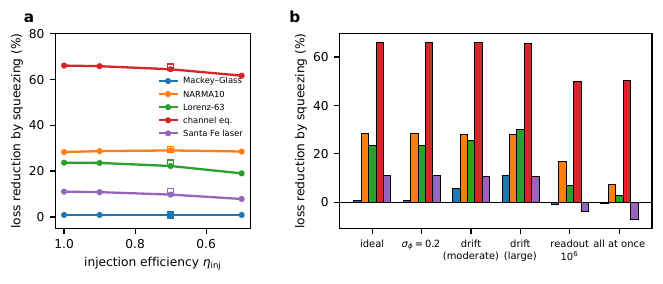

In [5]:
subprocess.run([sys.executable, 'make_rev.py'], check=True, capture_output=True); show('../paper/figs/fig_nonideal.pdf')

## Interpretation
Injection loss down to $\eta_{\rm inj}=0.5$, phase jitter up to 0.3 rad and drift barely change the gain; the readout is the binding constraint.